In [23]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# File paths
BASE = r"C:\Users\vimuk\Documents\Y2S1\AIML\2025-Y2-S1-MLB-B12G2-10"
DATA_PATH = os.path.join(BASE, "data", "processed", "Student_Performance_cleaned.csv")
RESULTS_DIR = os.path.join(BASE, "results")
METRICS_DIR = os.path.join(RESULTS_DIR, "metrics")
MODEL_OUTPUT_DIR = os.path.join(RESULTS_DIR, "model_outputs", "trained_models")

os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

MY_RESULTS_CSV = os.path.join(METRICS_DIR, "IT24103519_results.csv")
MY_MODEL_PKL = os.path.join(MODEL_OUTPUT_DIR, "IT24103519_best_model.pkl")
MY_METADATA_JSON = os.path.join(MODEL_OUTPUT_DIR, "IT24103519_model_info.json")
RANDOM_STATE = 42

In [27]:
df = pd.read_csv(DATA_PATH, sep=None, engine='python')

print("Shape:", df.shape)
display(df.head())
display(df.describe().T)
print("Missing values per column:\n", df.isnull().sum())

Shape: (9873, 7)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,StudyEfficiency
0,7,99,1,9,1,91.0,0.700000
1,4,82,0,4,2,65.0,0.800000
2,8,51,1,7,2,45.0,1.000000
3,5,52,1,5,2,36.0,0.833333
4,7,75,0,8,5,66.0,0.777778


,count,mean,std,min,25%,50%,75%,max
Hours Studied,9873.0,4.992100,2.589081,1.0,3.000,5.000000,7.0,9.0
Previous Scores,9873.0,69.441102,17.325601,40.0,54.000,69.000000,85.0,99.0
Extracurricular Activities,9873.0,0.494986,0.500000,0.0,0.000,0.000000,1.0,1.0
Sleep Hours,9873.0,6.531652,1.697683,4.0,5.000,7.000000,8.0,9.0
Sample Question Papers Practiced,9873.0,4.583004,2.867202,0.0,2.000,5.000000,7.0,9.0
Performance Index,9873.0,55.216651,19.208570,10.0,40.000,55.000000,70.0,100.0
StudyEfficiency,9873.0,0.699927,0.408383,0.1,0.375,0.666667,1.0,1.8


Missing values per column:
 Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
StudyEfficiency                     0
dtype: int64


In [28]:
# Define Features & Target

target = "Performance Index"
X = df.drop(columns=[target])
y = df[target]

print("Features:", list(X.columns))
print("Target:", target)

Features: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'StudyEfficiency']
Target: Performance Index


In [29]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (7898, 6)
Test shape: (1975, 6)


In [30]:
# Scale Features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# Model Varieties
# Base Random Forest

rf_base = RandomForestRegressor(random_state=RANDOM_STATE)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)

In [32]:
# Random Forest with max_depth tuning

rf_params_depth = {"max_depth": [3, 5, 7, 9, None]}
rf_depth_grid = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE),
                             rf_params_depth, cv=5, scoring="r2", n_jobs=-1)
rf_depth_grid.fit(X_train, y_train)

rf_best_depth = rf_depth_grid.best_estimator_
y_pred_depth = rf_best_depth.predict(X_test)

print("Best max_depth:", rf_depth_grid.best_params_)

Best max_depth: {'max_depth': 9}


In [33]:
# Random Forest with n_estimators + max_features tuning

rf_params_full = {
    "n_estimators": [50, 100, 200],
    "max_features": ["sqrt", "log2", None]
}

rf_full_grid = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE),
                            rf_params_full, cv=5, scoring="r2", n_jobs=-1)
rf_full_grid.fit(X_train, y_train)

rf_best_full = rf_full_grid.best_estimator_
y_pred_full = rf_best_full.predict(X_test)

print("Best params:", rf_full_grid.best_params_)

Best params: {'max_features': None, 'n_estimators': 200}


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- Define evaluate() before any models ---
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")
    return mae, rmse, r2

results = pd.DataFrame(columns=["Model","MAE","RMSE","R2"])
import warnings
warnings.filterwarnings("ignore")

def add_result(df, model_name, mae, rmse, r2):
    # Create new row as a dictionary matching df columns
    new_row_dict = {col: None for col in df.columns}
    new_row_dict.update({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    
    # Convert to DataFrame with same columns explicitly
    new_row = pd.DataFrame([new_row_dict], columns=df.columns)
    
    # Concatenate
    return pd.concat([df, new_row], ignore_index=True)

# Random Forest Models

# Base Random Forest
rf_base = RandomForestRegressor(random_state=RANDOM_STATE)
rf_base.fit(X_train_scaled, y_train)
y_pred_base = rf_base.predict(X_test_scaled)
mae, rmse, r2 = evaluate(y_test, y_pred_base, "RF Base")
results = add_result(results, "RF Base", mae, rmse, r2)

# RF with max_depth tuning
rf_depth = RandomForestRegressor(max_depth=10, random_state=RANDOM_STATE)
rf_depth.fit(X_train_scaled, y_train)
y_pred_depth = rf_depth.predict(X_test_scaled)
mae, rmse, r2 = evaluate(y_test, y_pred_depth, "RF Max Depth")
results = add_result(results, "RF Max Depth", mae, rmse, r2)

# GridSearch for hyperparameter tuning
rf = RandomForestRegressor(random_state=RANDOM_STATE)
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", "log2", None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
best_rf = grid_search.best_estimator_
y_pred_grid = best_rf.predict(X_test_scaled)
mae, rmse, r2 = evaluate(y_test, y_pred_grid, "RF Grid Search")
results = add_result(results, "RF Grid Search", mae, rmse, r2)

RF Base - MAE: 1.9009, RMSE: 2.3745, R²: 0.9849
RF Max Depth - MAE: 1.8159, RMSE: 2.2791, R²: 0.9860
RF Grid Search - MAE: 1.8100, RMSE: 2.2703, R²: 0.9862


In [35]:
# Select Best Model

best_model_name = results.loc[results["R2"].idxmax(), "Model"]
print("Best Model:", best_model_name)

if best_model_name == "RF Base":
    best_model = rf_base
elif best_model_name == "RF Max Depth":
    best_model = rf_best_depth
else:
    best_model = rf_best_full

Best Model: RF Grid Search


In [36]:
# Save Model & Metrics

# Save model
joblib.dump(best_model, MY_MODEL_PKL)

# Save metrics
results.to_csv(MY_RESULTS_CSV, index=False)

# Save metadata
metadata = {
    "member_id": "IT24103519",
    "name": "Kalubowila G.N",
    "assigned_model": "Random Forest Regressor",
    "best_model_name": best_model_name,
    "best_params": (
        rf_depth_grid.best_params_ if "Depth" in best_model_name else
        rf_full_grid.best_params_ if "Full" in best_model_name else {}
    ),
}
with open(MY_METADATA_JSON, "w") as f:
    json.dump(metadata, f, indent=4)

print("Model, metrics, and metadata saved successfully!")

Model, metrics, and metadata saved successfully!


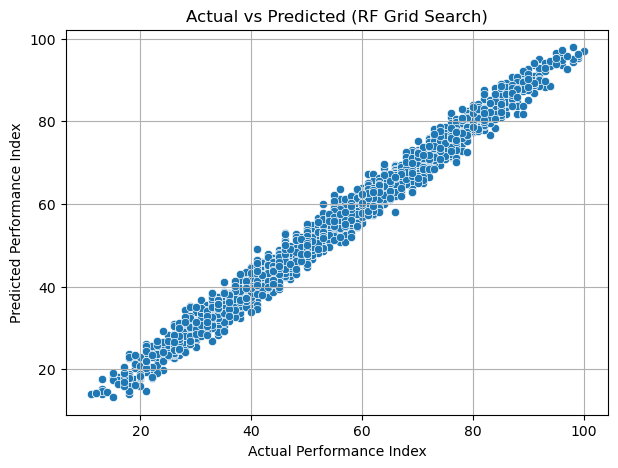

In [37]:
# Visualization — Actual vs Predicted

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=best_model.predict(X_test))
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.grid(True)
plt.show()